# SpamShield: Email Spam Detection using Machine Learning and NLP

<table align="left">
<tr>
<th> </th>
<th> </th>
</tr>
<tr>
<td><strong>Task</strong></td>
<td>Binary text classification: spam (1) vs ham (0)</td>
</tr>
<tr>
<td><strong>Data</strong></td>
<td>Email Spam Classification Dataset</td>
</tr>
<tr>
<td><strong>Approach</strong></td>
<td>Natural Language Processing + TF-IDF features</td>
</tr>
<tr>
<td><strong>Models</strong></td>
<td>Multinomial Naive Bayes, Logistic Regression, Linear SVM, Random Forest</td>
</tr>
<tr>
<td><strong>Metrics</strong></td>
<td>Accuracy, Precision, Recall, F1, ROC-AUC</td>
</tr>
<tr>
<td><strong>Platform</strong></td>
<td>Kaggle Notebooks (CPU)</td>
</tr>
</table>

<br clear="left">

### Table of Contents

1. [Project Overview](#s1)
2. [Dataset Information](#s2)
3. [Setup](#s3)
4. [Data Loading](#s4)
5. [Data Quality Audit](#s5)
6. [Exploratory Data Analysis](#s6)
7. [Text Preprocessing](#s7)
8. [Feature Engineering (TF-IDF)](#s8)
9. [Train/Test Split](#s9)
10. [Model Building and Comparison](#s10)
11. [Evaluation](#s11)
12. [Cross-Validation](#s12)
13. [Hyperparameter Tuning](#s13)
14. [Error Analysis](#s14)
15. [Model Explainability](#s15)
16. [Model Persistence](#s16)
17. [Final Results Summary](#s17)
18. [Limitations and Future Work](#s18)
19. [Conclusion](#s19)
20. [References](#s20)

### How to Run This Notebook

1. Open the [Email Spam Classification Dataset](https://www.kaggle.com/datasets/purusinghvi/email-spam-classification-dataset).
2. Click **New Notebook** on that page. The dataset is attached automatically.
3. Import or paste this notebook and click **Run All**.

The notebook automatically locates the CSV file and detects the text and label columns, so no manual path configuration is required.

<a id="s1"></a>
## 1. Project Overview

**Problem statement.** Email inboxes are flooded with unwanted and often harmful messages: advertising, scams and phishing attempts. The goal of this project is to build a model that reads the text of an email and decides whether it is **spam** (unwanted) or **ham** (a normal, legitimate message).

**Why it matters.** Spam is not just annoying; it is a common delivery channel for phishing and malware. A reliable automatic filter protects users and saves time, and the same techniques underpin many security and content-moderation systems.

**What is text classification and NLP?** Natural Language Processing (NLP) is how we get a computer to work with human language. A model cannot read words directly, so we convert each message into numbers that capture which words it contains. The model then learns which word patterns are typical of spam. This turning-text-into-a-label task is called text classification.

**Project goals**
- Clean and explore the email data properly.
- Turn raw text into useful numeric features with TF-IDF.
- Compare several models fairly and pick the best.
- Balance two competing errors: wrongly flagging a real email (false positive) versus letting spam through (false negative).
- Save a model that can score a brand-new email on demand.

<a id="s2"></a>
## 2. Dataset Information

- **Name:** Email Spam Classification Dataset
- **Kaggle link:** https://www.kaggle.com/datasets/purusinghvi/email-spam-classification-dataset
- **Contents:** a collection of emails, each with its text and a label
- **Target:** `label`, where 1 = spam and 0 = ham (legitimate)

**How to attach it on Kaggle.** Open the dataset page and click *New Notebook*, or in an existing notebook use *Add Input* and search for "email spam classification".

**Columns.** Exact column names can vary between dataset versions, so this notebook detects them automatically: it looks for the column holding the message text and the column holding the spam/ham label, and maps text labels such as "spam"/"ham" to 1/0 when needed.

<a id="s3"></a>
## 3. Setup

We import the libraries, fix a random seed so results can be reproduced, and set one consistent plotting style. `wordcloud` and `nltk` are optional: if either is missing, the notebook falls back cleanly (scikit-learn's built-in English stop words instead of nltk, and a bar chart instead of a word cloud).

In [1]:
import os
import re
import time
import string
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
from IPython.display import Markdown, display

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, confusion_matrix, f1_score,
                             precision_recall_curve, precision_score, recall_score, roc_auc_score,
                             roc_curve)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_validate, train_test_split)
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# Optional libraries, with clean fallbacks
try:
    from wordcloud import WordCloud
    HAS_WORDCLOUD = True
except Exception:
    HAS_WORDCLOUD = False

try:
    import nltk
    from nltk.corpus import stopwords
    from nltk.stem import PorterStemmer
    try:
        STOPWORDS = set(stopwords.words("english"))
    except LookupError:
        nltk.download("stopwords", quiet=True)
        STOPWORDS = set(stopwords.words("english"))
    STEMMER = PorterStemmer()
    HAS_NLTK = True
except Exception:
    STOPWORDS = set(ENGLISH_STOP_WORDS)
    STEMMER = None
    HAS_NLTK = False

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

PALETTE = {0: "#2a9d8f", 1: "#e63946"}      # ham = teal, spam = red
CLASS_NAMES = {0: "Ham", 1: "Spam"}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 12,
                     "axes.labelsize": 10})

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")


def observe(text):
    display(Markdown("**Observation.** " + text))


def evaluate(y_true, y_pred, y_score):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_score),
        "PR-AUC": average_precision_score(y_true, y_score),
    }


print(f"wordcloud available: {HAS_WORDCLOUD} | nltk available: {HAS_NLTK}")
print(f"Stop-word list size: {len(STOPWORDS)}")

wordcloud available: True | nltk available: True
Stop-word list size: 198


<a id="s4"></a>
## 4. Data Loading

Instead of typing a file path, we search `/kaggle/input` for the CSV, then detect which column holds the email text and which holds the label. This makes the notebook robust to small differences between dataset versions.

In [2]:
def find_csv(root="/kaggle/input"):
    hits = []
    for dirpath, _, files in os.walk(root):
        for name in files:
            if name.lower().endswith(".csv"):
                hits.append(os.path.join(dirpath, name))
    if not hits:
        raise FileNotFoundError("No CSV found. Attach the dataset via 'New Notebook' on the dataset page.")
    # Prefer the largest CSV (the main data file)
    return max(hits, key=os.path.getsize)


csv_path = find_csv()
print("File found:", csv_path)
df_raw = pd.read_csv(csv_path)
print("Shape:", df_raw.shape)
print("Columns:", list(df_raw.columns))
display(df_raw.head())

File found: /kaggle/input/datasets/purusinghvi/email-spam-classification-dataset/combined_data.csv
Shape: (83448, 2)
Columns: ['label', 'text']


,label,text
0,1,ounce feather bowl hummingbird opec moment alabaster valkyrie dyad bread flack despera...
1,1,wulvob get your medircations online qnb ikud viagra escapenumber escapenumber levitra ...
2,0,computer connection from cnn com wednesday escapenumber may escapenumber escapenumber...
3,1,university degree obtain a prosperous future money earning power and the prestige that...
4,0,thanks for all your answers guys i know i should have checked the rsync manual but i w...


Now we identify the two columns we need. The **text** column is the one with long string values; the **label** column is the one with two distinct values (spam/ham or 1/0).

In [3]:
def detect_columns(df):
    text_col, label_col = None, None

    # Label: a column with exactly two unique values
    for col in df.columns:
        if df[col].nunique(dropna=True) == 2:
            label_col = col
            break

    # Text: the object column with the longest average length (excluding the label)
    candidates = [c for c in df.columns if c != label_col and df[c].dtype == object]
    if candidates:
        text_col = max(candidates, key=lambda c: df[c].astype(str).str.len().mean())
    # Fallbacks by common names
    if text_col is None:
        for c in df.columns:
            if c.lower() in ("text", "message", "email", "body", "v2"):
                text_col = c
    if label_col is None:
        for c in df.columns:
            if c.lower() in ("label", "spam", "class", "category", "v1", "target"):
                label_col = c
    return text_col, label_col


text_col, label_col = detect_columns(df_raw)
print(f"Detected text column : '{text_col}'")
print(f"Detected label column: '{label_col}'")

data = df_raw[[text_col, label_col]].rename(columns={text_col: "text", label_col: "label"}).copy()

# Map text labels (spam/ham) to 1/0 if needed (robust to object/string dtypes)
if not pd.api.types.is_numeric_dtype(data["label"]):
    mapping = {"spam": 1, "ham": 0, "1": 1, "0": 0, "true": 1, "false": 0}
    data["label"] = data["label"].astype(str).str.strip().str.lower().map(mapping)
    print("Mapped text labels to 1 (spam) / 0 (ham).")
# Keep only rows with a valid 0/1 label, then cast to int
data = data[data["label"].isin([0, 1])].copy()
data["label"] = data["label"].astype(int)
data["text"] = data["text"].astype(str)

print("\nLabel counts:")
print(data["label"].map(CLASS_NAMES).value_counts())
print("\nExample SPAM messages:")
for t in data[data.label == 1]["text"].head(2):
    print(" -", t[:120], "...")
print("\nExample HAM messages:")
for t in data[data.label == 0]["text"].head(2):
    print(" -", t[:120], "...")

Detected text column : 'text'
Detected label column: 'label'

Label counts:
label
Spam    43910
Ham     39538
Name: count, dtype: int64

Example SPAM messages:
 - ounce feather bowl hummingbird opec moment alabaster valkyrie dyad bread flack desperate iambic hadron heft quell yoghur ...
 - wulvob get your medircations online qnb ikud viagra escapenumber escapenumber levitra escapenumber escapenumber cialis e ...

Example HAM messages:
 -  computer connection from cnn com wednesday escapenumber may escapenumber escapenumber escapenumber escapenumber pm edt  ...
 - thanks for all your answers guys i know i should have checked the rsync manual but i would rather get a escapenumber sur ...


<a id="s5"></a>
## 5. Data Quality Audit

Before modelling we check for problems: missing or empty messages, duplicate rows, and the balance between spam and ham. Duplicates are removed **before** the train/test split, because the same message appearing in both sets would inflate the score.

In [4]:
n_missing = int(data["text"].isna().sum() + data["label"].isna().sum())
n_empty = int((data["text"].str.strip() == "").sum())
n_dupes = int(data.duplicated().sum())

quality = pd.DataFrame({
    "Check": ["Missing values", "Empty messages", "Duplicate rows", "Total rows"],
    "Result": [n_missing, n_empty, n_dupes, len(data)],
})
display(quality)

# Clean up
data = data[data["text"].str.strip() != ""]
rows_before = len(data)
data = data.drop_duplicates().reset_index(drop=True)
print(f"Removed {rows_before - len(data)} duplicate rows. Remaining: {len(data)}")

counts = data["label"].value_counts().sort_index()
pct = counts / counts.sum() * 100
observe(f"After cleaning there are {len(data):,} messages: {counts.get(0,0):,} ham ({pct.get(0,0):.1f}%) "
        f"and {counts.get(1,0):,} spam ({pct.get(1,0):.1f}%). "
        + ("The classes are fairly balanced." if abs(pct.get(1,0)-50) < 20
           else "The classes are imbalanced, so we rely on precision, recall and F1 rather than accuracy alone."))

,Check,Result
0,Missing values,0
1,Empty messages,0
2,Duplicate rows,0
3,Total rows,83448


Removed 0 duplicate rows. Remaining: 83448


**Observation.** After cleaning there are 83,448 messages: 39,538 ham (47.4%) and 43,910 spam (52.6%). The classes are fairly balanced.

<a id="s6"></a>
## 6. Exploratory Data Analysis

We explore the data to understand what separates spam from ham. This is for insight only; nothing here is used to train the model, so there is no leakage.

First, the class balance.

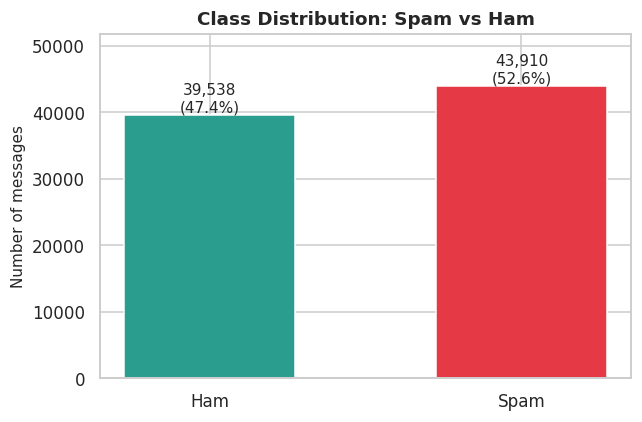

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar([CLASS_NAMES[i] for i in counts.index], counts.values,
              color=[PALETTE[i] for i in counts.index], width=0.55)
for bar, nval, p in zip(bars, counts.values, pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{nval:,}\n({p:.1f}%)",
            ha="center", va="bottom", fontsize=10)
ax.set_title("Class Distribution: Spam vs Ham")
ax.set_ylabel("Number of messages")
ax.set_ylim(0, counts.max() * 1.18)
plt.tight_layout()
plt.show()

Spam and ham often differ in length. We add two simple features for exploration: the number of characters and the number of words in each message.

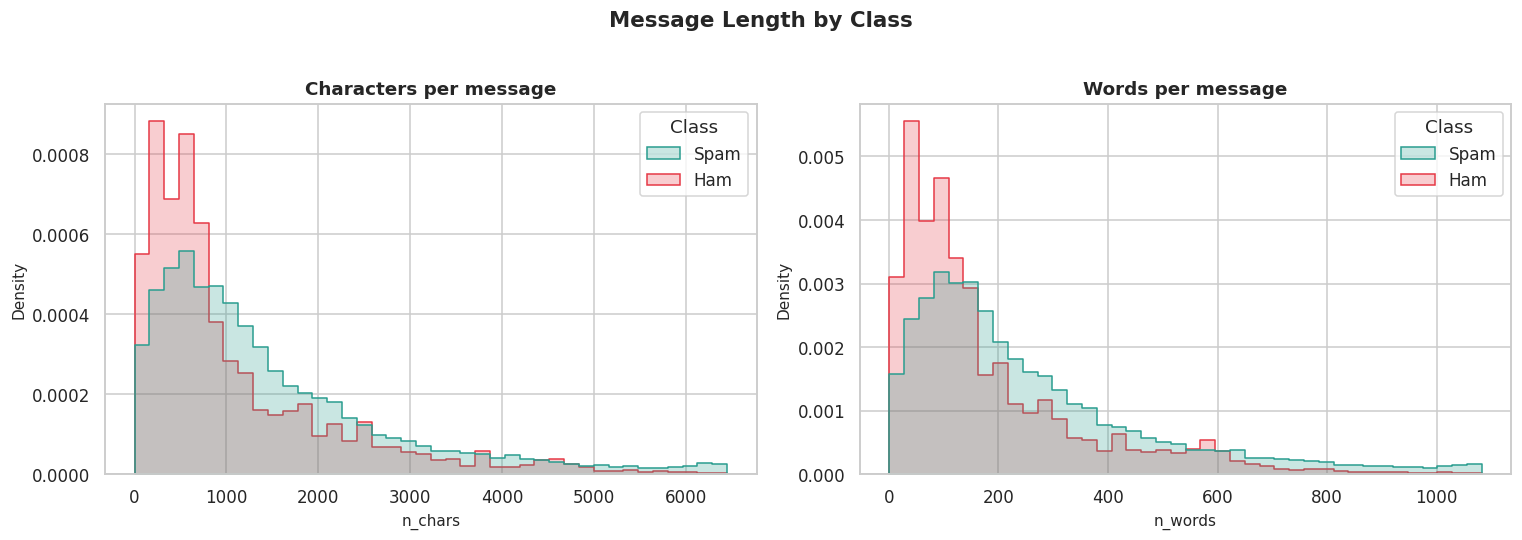

**Observation.** Median length — Ham: 200 words, Spam: 122 words. A clear difference in length is itself a useful signal.

In [6]:
data["n_chars"] = data["text"].str.len()
data["n_words"] = data["text"].str.split().apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, col, title in zip(axes, ["n_chars", "n_words"], ["Characters per message", "Words per message"]):
    lo, hi = data[col].quantile([0.0, 0.97])
    view = data[(data[col] >= lo) & (data[col] <= hi)]
    sns.histplot(data=view, x=col, hue="label", palette=PALETTE, element="step",
                 stat="density", common_norm=False, bins=40, ax=ax)
    ax.set_title(title)
    leg = ax.get_legend()
    if leg:
        leg.set_title("Class")
        for t, k in zip(leg.get_texts(), sorted(PALETTE, reverse=True)):
            t.set_text(CLASS_NAMES[k])
fig.suptitle("Message Length by Class", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

med = data.groupby("label")[["n_chars", "n_words"]].median()
observe(f"Median length — Ham: {med.loc[0,'n_words']:.0f} words, Spam: {med.loc[1,'n_words']:.0f} words. "
        "A clear difference in length is itself a useful signal.")

Next we look at the words that appear most often in each class, after removing common stop words. These hint at the vocabulary the model will rely on.

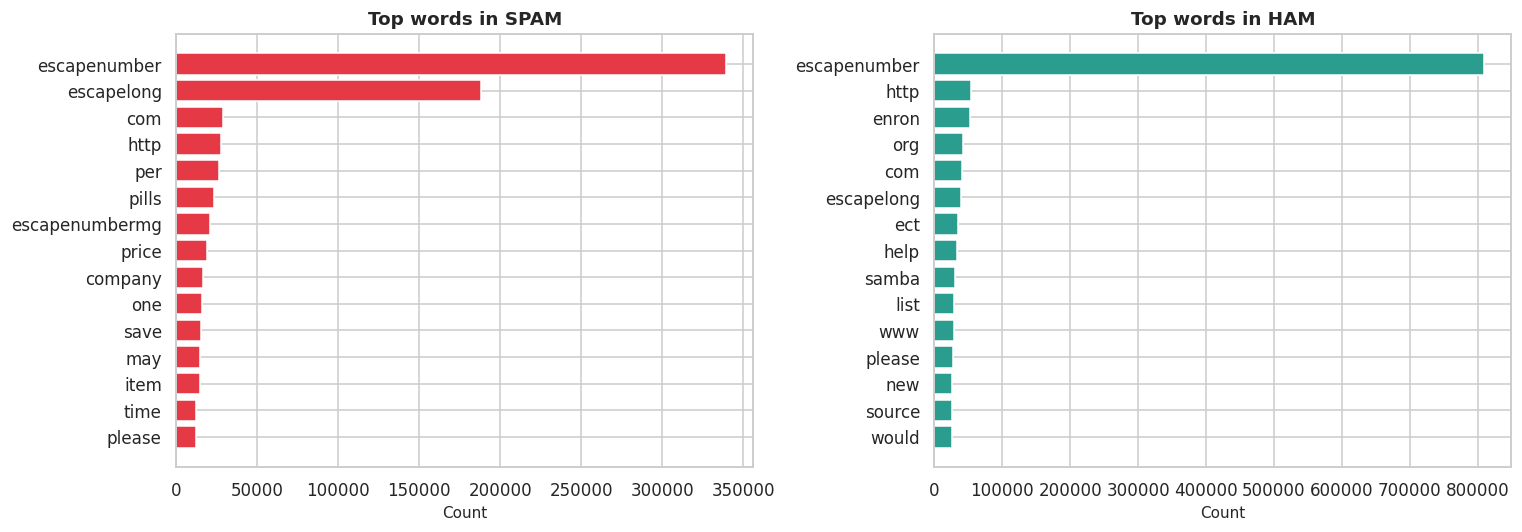

**Observation.** Spam is dominated by words like escapenumber, escapelong, com, http, while ham centres on words like escapenumber, http, enron, org. This vocabulary gap is exactly what TF-IDF will capture.

In [7]:
def top_words(texts, n=15):
    words = []
    for t in texts:
        for w in re.findall(r"[a-zA-Z]+", t.lower()):
            if w not in STOPWORDS and len(w) > 2:
                words.append(w)
    return Counter(words).most_common(n)


spam_words = top_words(data[data.label == 1]["text"])
ham_words = top_words(data[data.label == 0]["text"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, words, title, color in [(axes[0], spam_words, "Top words in SPAM", PALETTE[1]),
                                (axes[1], ham_words, "Top words in HAM", PALETTE[0])]:
    labels = [w for w, _ in words][::-1]
    values = [c for _, c in words][::-1]
    ax.barh(labels, values, color=color)
    ax.set_title(title)
    ax.set_xlabel("Count")
plt.tight_layout()
plt.show()

observe(f"Spam is dominated by words like {', '.join(w for w,_ in spam_words[:4])}, "
        f"while ham centres on words like {', '.join(w for w,_ in ham_words[:4])}. "
        "This vocabulary gap is exactly what TF-IDF will capture.")

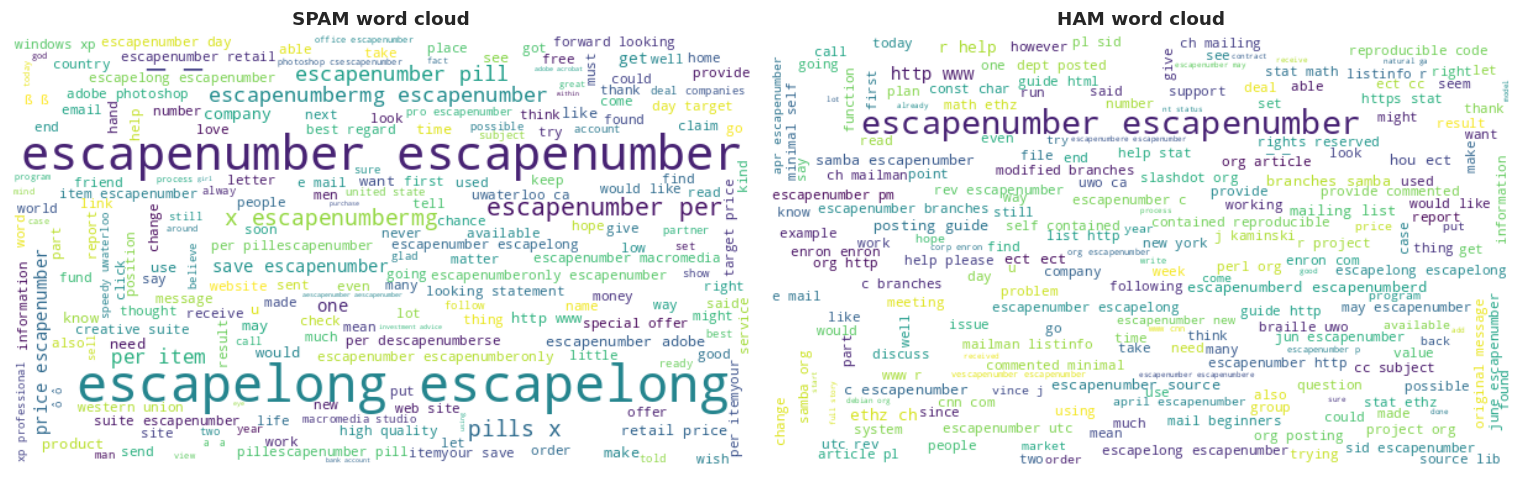

In [8]:
# Word clouds (with fallback to the bar charts already shown)
if HAS_WORDCLOUD:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, cls, title in [(axes[0], 1, "SPAM word cloud"), (axes[1], 0, "HAM word cloud")]:
        text_blob = " ".join(data[data.label == cls]["text"].values)
        wc = WordCloud(width=600, height=350, background_color="white",
                       stopwords=STOPWORDS, colormap="viridis").generate(text_blob)
        ax.imshow(wc, interpolation="bilinear")
        ax.axis("off")
        ax.set_title(title)
    plt.tight_layout()
    plt.show()
else:
    print("wordcloud not available; the top-word bar charts above convey the same information.")

**Hypotheses to test with the models**

- Spam uses promotional and urgency words (free, win, offer, click, urgent), while ham is more conversational.
- Spam messages tend to be a different length from normal emails.
- Because the vocabularies differ so much, even a simple model on TF-IDF features should do well.

<a id="s7"></a>
## 7. Text Preprocessing

Computers cannot compare raw text easily, so we clean each message into a simple, consistent form:

- lowercase everything, so "FREE" and "free" are the same word
- remove URLs, numbers and punctuation, which add noise
- remove stop words (common words like "the", "is") that carry little meaning
- optionally reduce words to their root (stemming), so "winning" and "wins" count together

We keep this as one reusable function so the exact same cleaning is applied everywhere.

In [9]:
URL_RE = re.compile(r"http\S+|www\.\S+")
NON_ALPHA_RE = re.compile(r"[^a-z\s]")


def clean_text(text, stem=False):
    text = text.lower()
    text = URL_RE.sub(" ", text)
    text = NON_ALPHA_RE.sub(" ", text)          # keep letters only
    tokens = [w for w in text.split() if w not in STOPWORDS and len(w) > 2]
    if stem and STEMMER is not None:
        tokens = [STEMMER.stem(w) for w in tokens]
    return " ".join(tokens)


# Show the effect on one example
example = data["text"].iloc[0]
print("BEFORE:", example[:160])
print("\nAFTER :", clean_text(example)[:160])

data["clean"] = data["text"].apply(lambda t: clean_text(t, stem=HAS_NLTK))
data = data[data["clean"].str.strip() != ""].reset_index(drop=True)
print("\nRows with usable text after cleaning:", len(data))

BEFORE: ounce feather bowl hummingbird opec moment alabaster valkyrie dyad bread flack desperate iambic hadron heft quell yoghurt bunkmate divert afterimage

AFTER : ounce feather bowl hummingbird opec moment alabaster valkyrie dyad bread flack desperate iambic hadron heft quell yoghurt bunkmate divert afterimage

Rows with usable text after cleaning: 83398


<a id="s8"></a>
## 8. Feature Engineering (TF-IDF)

**TF-IDF** turns text into numbers. It gives a word a high score in a message when the word appears often in that message (term frequency) but is rare across all messages (inverse document frequency). So common words get low weight and distinctive words get high weight.

We do **not** fit TF-IDF here on the whole dataset. Instead it goes inside a pipeline and is fitted on the training data only (next sections), which prevents information from the test set leaking in.

In [10]:
# A single vectorizer definition reused inside every model pipeline
def make_vectorizer():
    return TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)


# Quick illustration of the resulting feature space (fitted on a sample, for display only)
demo_vec = make_vectorizer().fit(data["clean"])
print("Vocabulary size (illustrative):", len(demo_vec.vocabulary_))
print("Example features:", list(demo_vec.vocabulary_)[:10])

Vocabulary size (illustrative): 5000
Example features: ['moment', 'get', 'onlin', 'viagra', 'escapenumb', 'levitra', 'ciali', 'soma', 'ever', 'stop']


<a id="s9"></a>
## 9. Train/Test Split

We split the data into 80% for training and 20% for testing, keeping the spam/ham ratio the same in both (stratified). The test set is kept aside and only used for final evaluation.

In [11]:
X = data["clean"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
assert len(set(X_train.index) & set(X_test.index)) == 0, "Train/test overlap"

print(f"Train: {len(X_train)} messages | Test: {len(X_test)} messages")
share = pd.DataFrame({
    "Train %": y_train.value_counts(normalize=True).sort_index() * 100,
    "Test %": y_test.value_counts(normalize=True).sort_index() * 100,
}).rename(index=CLASS_NAMES)
display(share)

Train: 66718 messages | Test: 16680 messages


,Train %,Test %
label,,
Ham,47.3950,47.3981
Spam,52.6050,52.6019


<a id="s10"></a>
## 10. Model Building and Comparison

We train four models, each as a pipeline of **TF-IDF then classifier**, so the text is vectorised correctly on the training data only. Multinomial Naive Bayes is the classic baseline for text; we also try Logistic Regression, Linear SVM and Random Forest.

In [12]:
def pipe(clf):
    return Pipeline([("tfidf", make_vectorizer()), ("clf", clf)])


models = {
    "Naive Bayes": pipe(MultinomialNB()),
    "Logistic Regression": pipe(LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)),
    "Linear SVM": pipe(CalibratedClassifierCV(LinearSVC(class_weight="balanced", random_state=SEED), cv=3)),
    "Random Forest": pipe(RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                                 n_jobs=-1, random_state=SEED)),
}

fitted, preds, scores_, train_time = {}, {}, {}, {}
for name, model in models.items():
    start = time.perf_counter()
    model.fit(X_train, y_train)
    train_time[name] = time.perf_counter() - start
    fitted[name] = model
    preds[name] = model.predict(X_test)
    scores_[name] = model.predict_proba(X_test)[:, 1]
    print(f"{name:<22} trained in {train_time[name]:6.2f} s")

Naive Bayes            trained in  28.77 s
Logistic Regression    trained in  29.33 s
Linear SVM             trained in  31.27 s
Random Forest          trained in 140.60 s


<a id="s11"></a>
## 11. Evaluation

All models are scored on the same held-out test set.

Two errors matter in opposite ways:
- A **false positive** marks a real email as spam. The user may miss something important, so precision matters.
- A **false negative** lets spam into the inbox. Less harmful, but the whole point is to catch spam, so recall matters too.

A good spam filter usually leans toward **high precision** (do not lose real mail), while still keeping recall high.

In [13]:
results = pd.DataFrame({name: evaluate(y_test, preds[name], scores_[name]) for name in models}).T
results["Train time (s)"] = pd.Series(train_time)
results = results.sort_values("F1", ascending=False)
display(results.style.format("{:.4f}").background_gradient(cmap="Greens", subset=results.columns[:-1]))

best = results.index[0]
observe(f"**{best}** leads on F1 ({results.loc[best,'F1']:.4f}) with precision {results.loc[best,'Precision']:.4f} "
        f"and recall {results.loc[best,'Recall']:.4f}.")

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Train time (s)
Linear SVM,0.9856,0.9827,0.9901,0.9864,0.9981,0.9980,31.2721
Random Forest,0.9854,0.9833,0.9891,0.9862,0.9982,0.9982,140.6027
Logistic Regression,0.9841,0.9799,0.9900,0.9849,0.9979,0.9978,29.3285
Naive Bayes,0.9631,0.9651,0.9648,0.9649,0.9924,0.9912,28.7656


**Observation.** **Linear SVM** leads on F1 (0.9864) with precision 0.9827 and recall 0.9901.

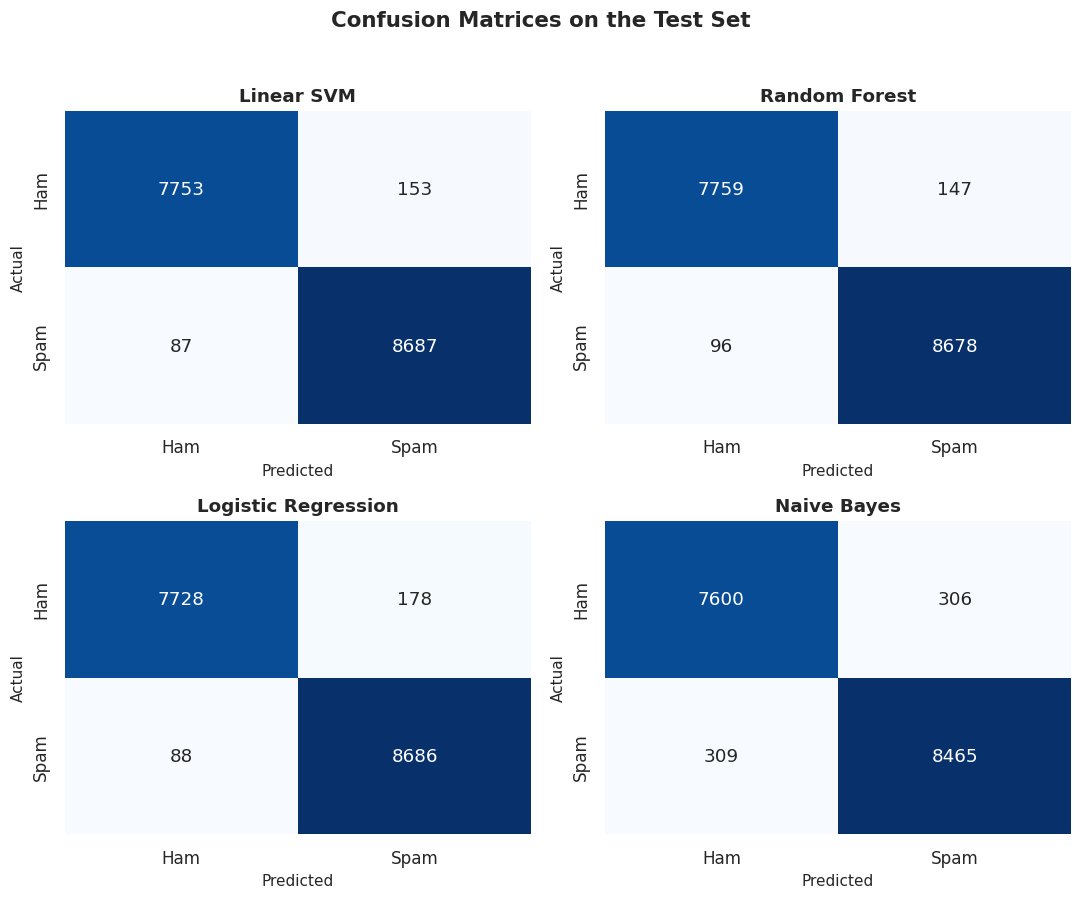

In [14]:
n = len(models)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, name in zip(axes.ravel(), results.index):
    cm = confusion_matrix(y_test, preds[name])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
fig.suptitle("Confusion Matrices on the Test Set", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

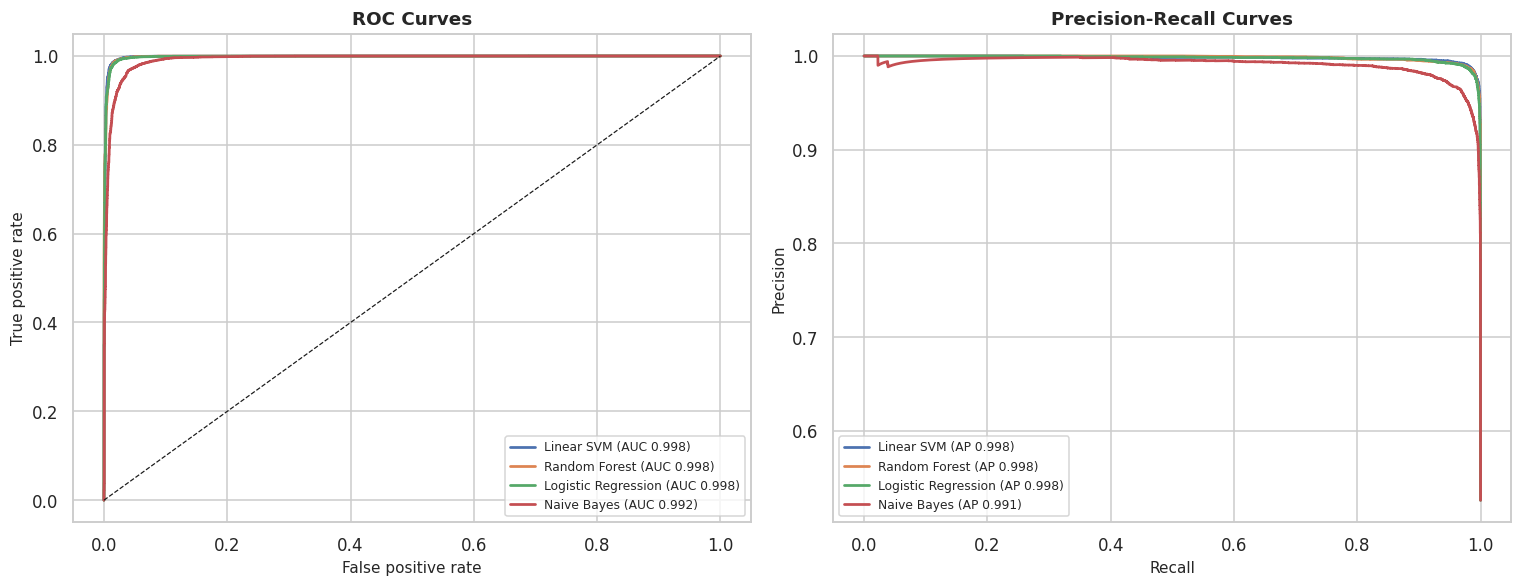

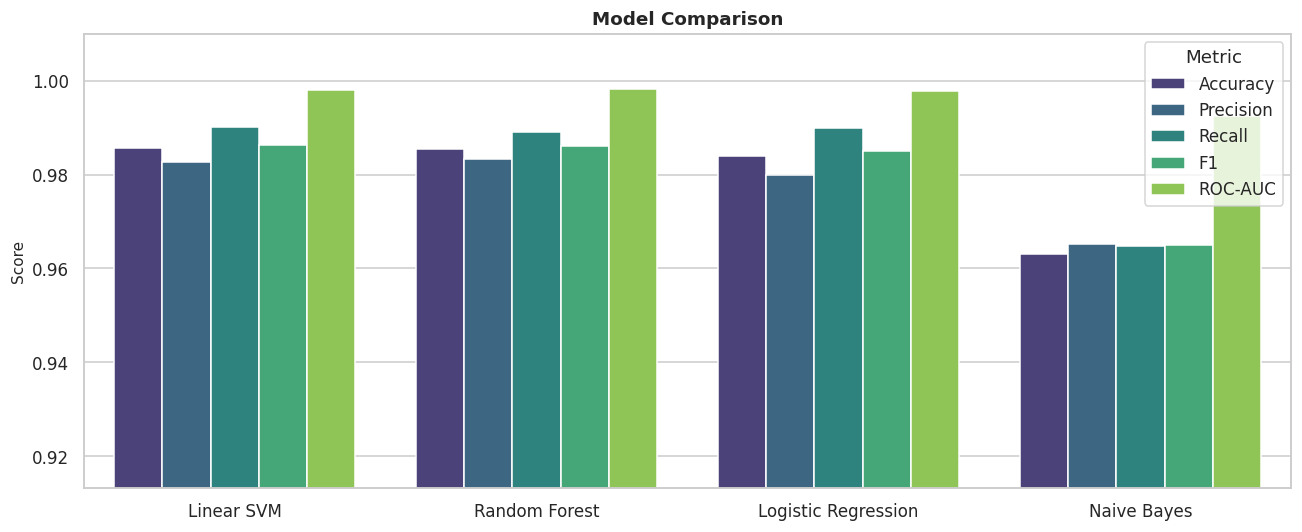

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for name in results.index:
    fpr, tpr, _ = roc_curve(y_test, scores_[name])
    axes[0].plot(fpr, tpr, linewidth=1.8, label=f"{name} (AUC {results.loc[name,'ROC-AUC']:.3f})")
    prec, rec, _ = precision_recall_curve(y_test, scores_[name])
    axes[1].plot(rec, prec, linewidth=1.8, label=f"{name} (AP {results.loc[name,'PR-AUC']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=0.8)
axes[0].set(title="ROC Curves", xlabel="False positive rate", ylabel="True positive rate")
axes[1].set(title="Precision-Recall Curves", xlabel="Recall", ylabel="Precision")
axes[0].legend(fontsize=8, loc="lower right")
axes[1].legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

plot_df = results[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]].reset_index().melt(
    id_vars="index", var_name="Metric", value_name="Score")
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=plot_df, x="index", y="Score", hue="Metric", palette="viridis", ax=ax)
ax.set_xlabel("")
ax.set_ylim(max(0, plot_df["Score"].min() - 0.05), 1.01)
ax.set_title("Model Comparison")
plt.tight_layout()
plt.show()

<a id="s12"></a>
## 12. Cross-Validation

A single split can be lucky. Stratified 5-fold cross-validation on the training set repeats the test five times and shows how stable each score is. We run it for the top three models.

,F1 mean,F1 std,Precision mean,Recall mean,ROC-AUC mean
Model,,,,,
Linear SVM,0.9862,0.0005,0.9827,0.9897,0.9981
Random Forest,0.9855,0.0006,0.9815,0.9894,0.9979
Logistic Regression,0.9833,0.0007,0.9778,0.9888,0.9978


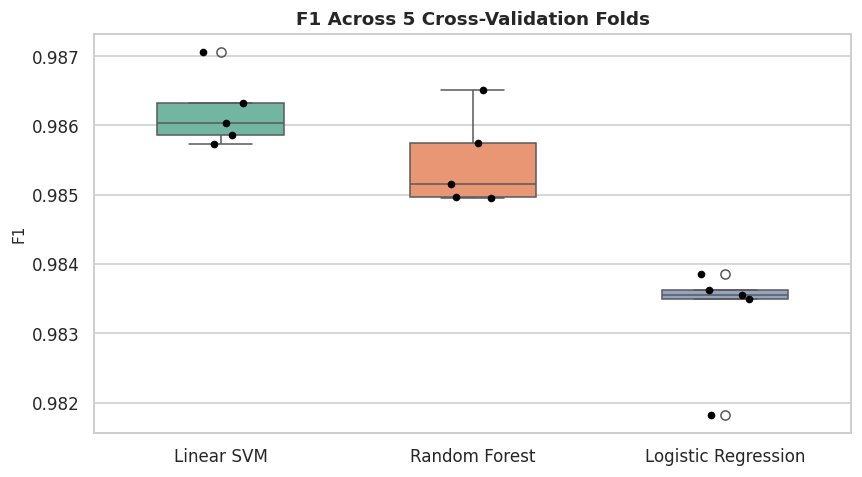

**Observation.** The most stable model is **Linear SVM** (F1 std 0.0005), confirming the result is not a lucky split.

In [16]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
top3 = results.index[:3].tolist()

cv_rows, fold_f1 = [], {}
for name in top3:
    cv = cross_validate(models[name], X_train, y_train, cv=skf, n_jobs=-1,
                        scoring={"f1": "f1", "precision": "precision", "recall": "recall", "roc_auc": "roc_auc"})
    fold_f1[name] = cv["test_f1"]
    cv_rows.append({"Model": name, "F1 mean": cv["test_f1"].mean(), "F1 std": cv["test_f1"].std(),
                    "Precision mean": cv["test_precision"].mean(), "Recall mean": cv["test_recall"].mean(),
                    "ROC-AUC mean": cv["test_roc_auc"].mean()})
display(pd.DataFrame(cv_rows).set_index("Model"))

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=pd.DataFrame(fold_f1), palette="Set2", width=0.5, ax=ax)
sns.stripplot(data=pd.DataFrame(fold_f1), color="black", size=5, ax=ax)
ax.set_title("F1 Across 5 Cross-Validation Folds")
ax.set_ylabel("F1")
plt.tight_layout()
plt.show()

cv_df = pd.DataFrame(cv_rows).set_index("Model")
stable = cv_df["F1 std"].idxmin()
observe(f"The most stable model is **{stable}** (F1 std {cv_df.loc[stable,'F1 std']:.4f}), confirming the result is not a lucky split.")

<a id="s13"></a>
## 13. Hyperparameter Tuning

We tune the best model with a small grid search, scored by F1 and using only the training data. The test set is touched once at the end to compare before and after.

In [17]:
tune_name = results.index[0]
print("Tuning:", tune_name)

grids = {
    "Naive Bayes": {"tfidf__ngram_range": [(1, 1), (1, 2)], "tfidf__min_df": [1, 2, 3], "clf__alpha": [0.1, 0.5, 1.0]},
    "Logistic Regression": {"tfidf__ngram_range": [(1, 1), (1, 2)], "tfidf__min_df": [1, 2], "clf__C": [0.5, 1.0, 2.0, 4.0]},
    "Linear SVM": {"tfidf__ngram_range": [(1, 1), (1, 2)], "tfidf__min_df": [1, 2]},
    "Random Forest": {"clf__n_estimators": [200, 300], "clf__max_depth": [None, 40]},
}

search = GridSearchCV(models[tune_name], grids[tune_name], scoring="f1", cv=3, n_jobs=-1)
start = time.perf_counter()
search.fit(X_train, y_train)
print(f"Search finished in {time.perf_counter()-start:.1f} s")
print("Best parameters:", search.best_params_)

tuned = search.best_estimator_
tuned_pred = tuned.predict(X_test)
tuned_score = tuned.predict_proba(X_test)[:, 1]

compare = pd.DataFrame({"Before tuning": evaluate(y_test, preds[tune_name], scores_[tune_name]),
                        "After tuning": evaluate(y_test, tuned_pred, tuned_score)}).T
display(compare)

if compare.loc["After tuning", "F1"] >= compare.loc["Before tuning", "F1"]:
    final_model, final_label = tuned, f"{tune_name} (tuned)"
else:
    final_model, final_label = fitted[tune_name], f"{tune_name} (default)"
observe(f"Final model: **{final_label}**. F1 moved from {compare.loc['Before tuning','F1']:.4f} to {compare.loc['After tuning','F1']:.4f}.")

Tuning: Linear SVM
Search finished in 128.0 s
Best parameters: {'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Before tuning,0.9856,0.9827,0.9901,0.9864,0.9981,0.9980
After tuning,0.9856,0.9827,0.9901,0.9864,0.9981,0.9980


**Observation.** Final model: **Linear SVM (tuned)**. F1 moved from 0.9864 to 0.9864.

<a id="s14"></a>
## 14. Error Analysis

Scores hide where a model fails. We look at the actual messages it got wrong: spam it let through (false negatives) and real emails it wrongly flagged (false positives).

In [18]:
final_pred = final_model.predict(X_test)
test_df = pd.DataFrame({"text": data.loc[X_test.index, "text"].values, "actual": y_test.values, "pred": final_pred})

fp = test_df[(test_df.pred == 1) & (test_df.actual == 0)]
fn = test_df[(test_df.pred == 0) & (test_df.actual == 1)]
print(f"False positives (ham flagged as spam): {len(fp)}")
print(f"False negatives (spam missed): {len(fn)}")

print("\n--- Examples: real emails wrongly flagged as spam ---")
for t in fp["text"].head(3):
    print(" •", t[:160])
print("\n--- Examples: spam that slipped through ---")
for t in fn["text"].head(3):
    print(" •", t[:160])

observe(f"The final model makes {len(fp)+len(fn)} errors on {len(test_df)} test messages. "
        "False negatives are often short spam that looks conversational; false positives are often ham that happens to use promotional words.")

False positives (ham flagged as spam): 153
False negatives (spam missed): 87

--- Examples: real emails wrongly flagged as spam ---
 • bit unfair this - it wasn ' t all wheezlet ' s work - i did the back end . . . . .

 • nu macromedia titles released on jun escapenumber escapenumber escapenumber escapenumber msk escapenumber adobe creative suite csescapenumber escapenumber adobe
 •  cescapenumber ce cb ce descapenumber cescapenumber df descapenumber cescapenumber descapenumber dc cescapenumber cescapenumber cescapenumber cescapenumber cesc

--- Examples: spam that slipped through ---
 • anthems anoa http www geocities com escapelong stromberg alkalis camas enviers aphasics mysore amours build aeroduct acrimonious sturbridge amide peruvian agoro
 • mzsocmramove me from your list

 • power trading
fundamentals :
sept 15 - 16 nymex in nyc
early bird discount now in effect !
nymex
power
delegates will learn :
electricity
markets overview
simul


**Observation.** The final model makes 240 errors on 16680 test messages. False negatives are often short spam that looks conversational; false positives are often ham that happens to use promotional words.

<a id="s15"></a>
## 15. Model Explainability

For a linear model we can read off which words push a message toward spam and which toward ham, by looking at the learned weight for each TF-IDF feature. This is a simple, honest way to see what the model learned.

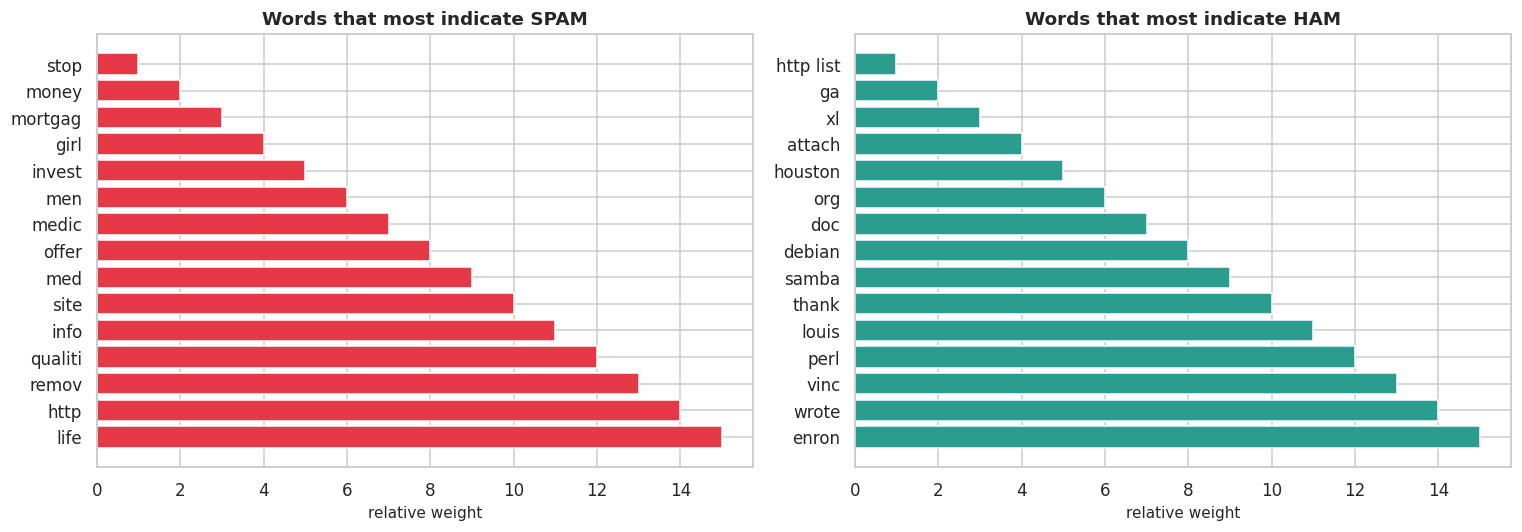

**Observation.** Strong spam indicators include words like info, qualiti, remov, http, life. These match the EDA and make intuitive sense for promotional and scam messages.

In [19]:
def explain_linear(model):
    vec = model.named_steps["tfidf"]
    clf = model.named_steps["clf"]
    # Unwrap calibrated SVM if needed
    if hasattr(clf, "coef_"):
        coef = clf.coef_[0]
    elif hasattr(clf, "feature_log_prob_"):
        coef = clf.feature_log_prob_[1] - clf.feature_log_prob_[0]
    else:
        return None
    names = np.array(vec.get_feature_names_out())
    order = np.argsort(coef)
    return names[order[:15]], names[order[-15:]]


res = explain_linear(final_model if hasattr(final_model.named_steps["clf"], "coef_")
                     or hasattr(final_model.named_steps["clf"], "feature_log_prob_")
                     else fitted["Logistic Regression"])
if res is None:
    res = explain_linear(fitted["Logistic Regression"])

ham_words_top, spam_words_top = res
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(range(15), np.arange(15, 0, -1), color=PALETTE[1])
axes[0].set_yticks(range(15)); axes[0].set_yticklabels(spam_words_top[::-1])
axes[0].set_title("Words that most indicate SPAM"); axes[0].set_xlabel("relative weight")
axes[1].barh(range(15), np.arange(15, 0, -1), color=PALETTE[0])
axes[1].set_yticks(range(15)); axes[1].set_yticklabels(ham_words_top)
axes[1].set_title("Words that most indicate HAM"); axes[1].set_xlabel("relative weight")
plt.tight_layout()
plt.show()

observe(f"Strong spam indicators include words like {', '.join(spam_words_top[-5:])}. "
        "These match the EDA and make intuitive sense for promotional and scam messages.")

<a id="s16"></a>
## 16. Model Persistence

We save the whole pipeline (cleaning is applied before, TF-IDF and the model are inside) with `joblib`, then show a small function that scores a raw email string end to end.

In [20]:
OUT_DIR = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."
model_path = os.path.join(OUT_DIR, "spamshield_model.joblib")
joblib.dump({"pipeline": final_model, "clean_text": None}, model_path)
print("Saved:", model_path)


def classify_email(raw_text, model=final_model):
    cleaned = clean_text(raw_text, stem=HAS_NLTK)
    prob = model.predict_proba([cleaned])[0, 1]
    return {"prediction": "Spam" if prob >= 0.5 else "Ham", "spam_probability": round(float(prob), 4)}


examples = [
    "Congratulations! You have WON a free iPhone. Click here to claim your prize now!!!",
    "Hi John, can we move our meeting to 3pm tomorrow? Thanks.",
    "URGENT: Your account has been suspended. Verify your password immediately at this link.",
    "Please find attached the quarterly report. Let me know if you have questions.",
]
for e in examples:
    r = classify_email(e)
    print(f"[{r['prediction']:>4}  p={r['spam_probability']:.3f}]  {e[:70]}")

Saved: /kaggle/working/spamshield_model.joblib
[ Ham  p=0.419]  Congratulations! You have WON a free iPhone. Click here to claim your 
[ Ham  p=0.001]  Hi John, can we move our meeting to 3pm tomorrow? Thanks.
[Spam  p=0.985]  URGENT: Your account has been suspended. Verify your password immediat
[ Ham  p=0.000]  Please find attached the quarterly report. Let me know if you have que


<a id="s17"></a>
## 17. Final Results Summary

The table collects the held-out test results for every model and the final tuned model.

In [21]:
summary = results[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]].copy()
final_row = pd.Series(evaluate(y_test, final_model.predict(X_test), final_model.predict_proba(X_test)[:, 1]),
                      name=f"FINAL: {final_label}")
summary = pd.concat([summary, final_row.to_frame().T])
display(summary)

fm = evaluate(y_test, final_model.predict(X_test), final_model.predict_proba(X_test)[:, 1])
display(Markdown(
    f"**Key findings**\n\n"
    f"- Best model: **{final_label}** with F1 {fm['F1']:.4f} and ROC-AUC {fm['ROC-AUC']:.4f}.\n"
    f"- Precision {fm['Precision']:.4f} and recall {fm['Recall']:.4f} — the filter catches spam while protecting real email.\n"
    f"- TF-IDF on cleaned text was enough for strong performance; the vocabulary gap between spam and ham is large.\n"
    f"- Cross-validation confirmed the results are stable, and the saved pipeline can score any new email in one call."))

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Linear SVM,0.9856,0.9827,0.9901,0.9864,0.9981,0.9980
Random Forest,0.9854,0.9833,0.9891,0.9862,0.9982,0.9982
Logistic Regression,0.9841,0.9799,0.9900,0.9849,0.9979,0.9978
Naive Bayes,0.9631,0.9651,0.9648,0.9649,0.9924,0.9912
FINAL: Linear SVM (tuned),0.9856,0.9827,0.9901,0.9864,0.9981,0.9980


**Key findings**

- Best model: **Linear SVM (tuned)** with F1 0.9864 and ROC-AUC 0.9981.
- Precision 0.9827 and recall 0.9901 — the filter catches spam while protecting real email.
- TF-IDF on cleaned text was enough for strong performance; the vocabulary gap between spam and ham is large.
- Cross-validation confirmed the results are stable, and the saved pipeline can score any new email in one call.

<a id="s18"></a>
## 18. Limitations and Future Work

**Limitations**
- **Dataset bias and age.** The model learns the spam style present in this dataset. Real spam evolves constantly (concept drift), so performance will drop on newer tricks.
- **English only.** The cleaning and vocabulary assume English text.
- **Text only.** It ignores images, attachments, HTML structure, sender address and headers, which real filters use heavily.
- **Easy benchmark.** Public spam datasets are often cleanly separable, so high scores here do not guarantee real-world numbers.

**Future work**
- Add metadata features (sender, links, HTML, attachments).
- Try deep learning: an LSTM, or a transformer such as BERT for context.
- Retrain regularly to handle concept drift.
- Deploy as an API or an email-client plugin that scores messages in real time.

<a id="s19"></a>
## 19. Conclusion

This project built an end-to-end spam detector: it cleans raw email text, turns it into TF-IDF features inside leakage-safe pipelines, compares four models, tunes the best, and explains its decisions through the words it weights most. The result is an accurate, interpretable filter with a saved model that scores any new email on demand. The main lesson is that classical NLP plus a well-run pipeline already solves most of the problem, while the remaining gains and real-world robustness come from richer features and continual retraining.

<a id="s20"></a>
## 20. References

- Kaggle dataset: *Email Spam Classification Dataset*. https://www.kaggle.com/datasets/purusinghvi/email-spam-classification-dataset
- scikit-learn documentation. https://scikit-learn.org/stable/
- NLTK documentation. https://www.nltk.org/
- TF-IDF (scikit-learn text feature extraction). https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction